# 02 — Pré-processamento

**Dimensão 4 da rubrica — 15 pontos.**

## Navegação
- [1. Definição do alvo e população](#prep-alvo)
  - [Distribuição das classes](#prep-distribuicao)
  - [Perfil por classe e gênero](#prep-perfil)
- [2. Dados ausentes](#prep-ausentes)
- [3. Marcador de emprego](#prep-emprego)
- [4. Engenharia de variáveis](#prep-features)
- [5. Escalonamento](#prep-escalonamento)
- [6. Exportação](#prep-exportacao)

As decisões de preparação são descritas junto aos códigos e resultados correspondentes.

<a id="prep-alvo"></a>
## 1. Definição do alvo e população de modelagem

Construímos `TARGET` a partir do histórico mensal de crédito. Os status 2, 3, 4 e 5 representam atrasos graves de pelo menos 60 dias; se algum deles aparece no histórico de um cliente, atribuímos `TARGET=1`, isto é, **com atraso grave de pagamento observado**. Quando nenhum desses status aparece, atribuímos `TARGET=0`, isto é, **sem atraso de pagamento grave observado no histórico**. Os rótulos “Maus Pagadores” e “Bons Pagadores” são usados como nomes das classes, mas não garantem o comportamento futuro.

A definição é retrospectiva: indica se houve ao menos uma ocorrência de inadimplência grave no período observado. Não representa uma previsão de inadimplência em uma janela futura fixa.

In [52]:
from pathlib import Path
import numpy as np
import pandas as pd

# 1. Definir os caminhos e carregar os datasets brutos com pandas
path_app = Path("../data/raw/application_record.csv")
path_cred = Path("../data/raw/credit_record.csv")

df_app = pd.read_csv(path_app)
df_cred = pd.read_csv(path_cred)

print(f'Dimensão original do Cadastro (application_record.csv): {df_app.shape}')
print(f'Dimensão original do Histórico (credit_record.csv): {df_cred.shape}')

# 2. Construção da Variável Alvo (Target) baseada na regra de inadimplência (60+ dias de atraso)
maus_pagadores_status = ['2', '3', '4', '5']
df_cred['TARGET_TEMP'] = df_cred['STATUS'].astype(str).apply(
    lambda x: 1 if x in maus_pagadores_status else 0
)

# Agrupar por ID para capturar o pior status histórico do cliente (.max())
clientes_alvo = df_cred.groupby('ID')['TARGET_TEMP'].max().reset_index()
clientes_alvo.rename(columns={'TARGET_TEMP': 'TARGET'}, inplace=True)

# 3. Realizar o Inner Join para isolar a população de modelagem com histórico válido
df_modelagem = pd.merge(df_app, clientes_alvo, on='ID', how='inner')

print(f'\nDimensão da base unificada de modelagem (Inner Join): {df_modelagem.shape}')

# Cálculo e formatação da proporção da variável Target (2 casas decimais e símbolo %)
proporcoes = (df_modelagem['TARGET'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
print(f"Proporção da Target na população de modelagem:\n{proporcoes.to_string()}")

Dimensão original do Cadastro (application_record.csv): (438557, 18)
Dimensão original do Histórico (credit_record.csv): (1048575, 3)

Dimensão da base unificada de modelagem (Inner Join): (36457, 19)
Proporção da Target na população de modelagem:
TARGET
0    98.31%
1     1.69%


<a id="prep-distribuicao"></a>
### 1.1 Cruzamento das bases e distribuição do alvo

O cruzamento interno por ID conserva clientes presentes no cadastro e no histórico e produz a população usada na modelagem. A saída mostra 36.457 registros e 19 colunas. Nesta população, `TARGET=0` representa clientes sem atraso de pagamento grave observado no histórico; `TARGET=1` representa clientes com atraso grave de pagamento observado. Os rótulos “Bons Pagadores” e “Maus Pagadores” são usados como nomes das classes na visualização, sem indicar garantia de comportamento futuro.

A proporção difere daquela calculada no Notebook 01 sobre todo o histórico (98,55% e 1,45%), pois o cruzamento define outra população. A diferença observada, isoladamente, não permite concluir que houve ou não viés de seleção. A tabela e o gráfico abaixo descrevem a quantidade e o percentual de cada classe na população efetivamente cruzada.

,Classe,Quantidade de clientes,Percentual (%)
0,Bons Pagadores (TARGET=0),35841,98.31
1,Maus Pagadores (TARGET=1),616,1.69


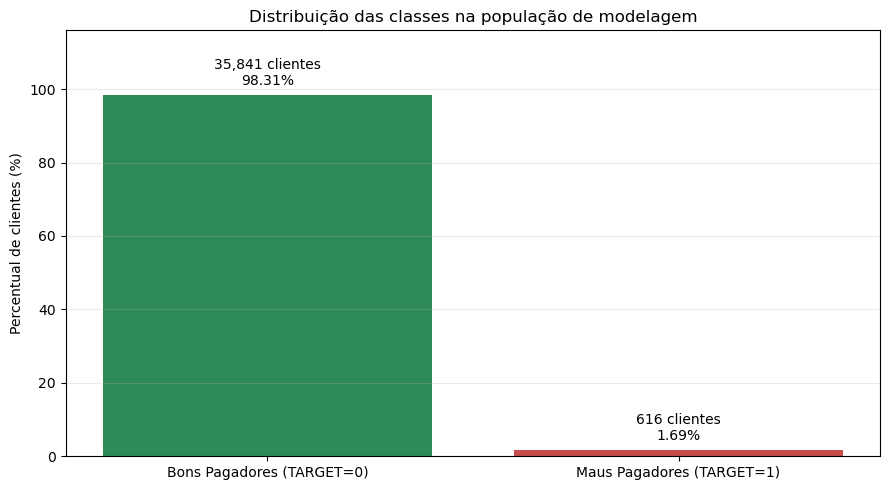

In [53]:
import matplotlib.pyplot as plt
from IPython.display import display

quantidades = df_modelagem['TARGET'].value_counts().reindex([0, 1], fill_value=0)
distribuicao_target = pd.DataFrame({
    'Classe': ['Bons Pagadores (TARGET=0)', 'Maus Pagadores (TARGET=1)'],
    'Quantidade de clientes': quantidades.values,
    'Percentual (%)': (quantidades / len(df_modelagem) * 100).round(2).values
})

display(distribuicao_target)

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(
    distribuicao_target['Classe'],
    distribuicao_target['Percentual (%)'],
    color=['#2E8B57', '#C94C4C']
)

for barra, quantidade, percentual in zip(
    barras,
    distribuicao_target['Quantidade de clientes'],
    distribuicao_target['Percentual (%)']
):
    ax.annotate(
        f'{quantidade:,} clientes\n{percentual:.2f}%',
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom'
    )

ax.set_title('Distribuição das classes na população de modelagem')
ax.set_ylabel('Percentual de clientes (%)')
ax.set_ylim(0, distribuicao_target['Percentual (%)'].max() * 1.18)
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** A altura das barras compara a participação percentual de cada classe na população de modelagem; os rótulos exibem também a quantidade de clientes. A diferença entre as classes evidencia o desbalanceamento observado após o cruzamento das bases.

<a id="prep-perfil"></a>
### 1.2 Perfil descritivo por classe e gênero

Para caracterizar a população cruzada, comparamos idade, renda, número de filhos, tamanho familiar e proporções de propriedade de imóvel e carro por classe do `TARGET` e gênero. A tabela apresenta média e mediana para idade e renda. Nos gráficos, usamos as medianas de idade e renda: a média considera todos os valores, mas pode ser deslocada por rendas muito altas; a mediana representa o valor central e é menos sensível a valores extremos. Assim, os gráficos destacam o perfil central, enquanto a tabela mantém as médias para comparação. A fonte consultada não especifica a moeda nem o período de referência de `AMT_INCOME_TOTAL`; por isso, apresentamos os valores monetários registrados sem atribuir moeda ou periodicidade. As proporções patrimoniais indicam somente associação descritiva nesta população, não causalidade nem comportamento futuro.

Classe histórica,Gênero,Clientes,"Idade média (mediana), anos",Renda média (mediana)*,Filhos (média),Pessoas por família (média),Com imóvel (%),Com carro (%),Profissionais de segurança (%),Outros/ocupação não informada (%),Profissionais de TI (%)
Bons Pagadores,Mulheres,"24,051",44.9 (44),172.627 (157.500),0.39,2.13,69.0%,25.7%,0.7%,36.0%,0.1%
Bons Pagadores,Homens,"11,790",39.9 (39),215.407 (202.500),0.51,2.34,64.0%,63.2%,3.5%,21.0%,0.3%
Maus Pagadores,Mulheres,379,45.6 (46),168.212 (157.500),0.40,2.12,62.5%,26.4%,0.5%,39.3%,0.8%
Maus Pagadores,Homens,237,39.1 (38),214.094 (180.000),0.48,2.22,54.0%,52.3%,4.6%,19.0%,0.0%


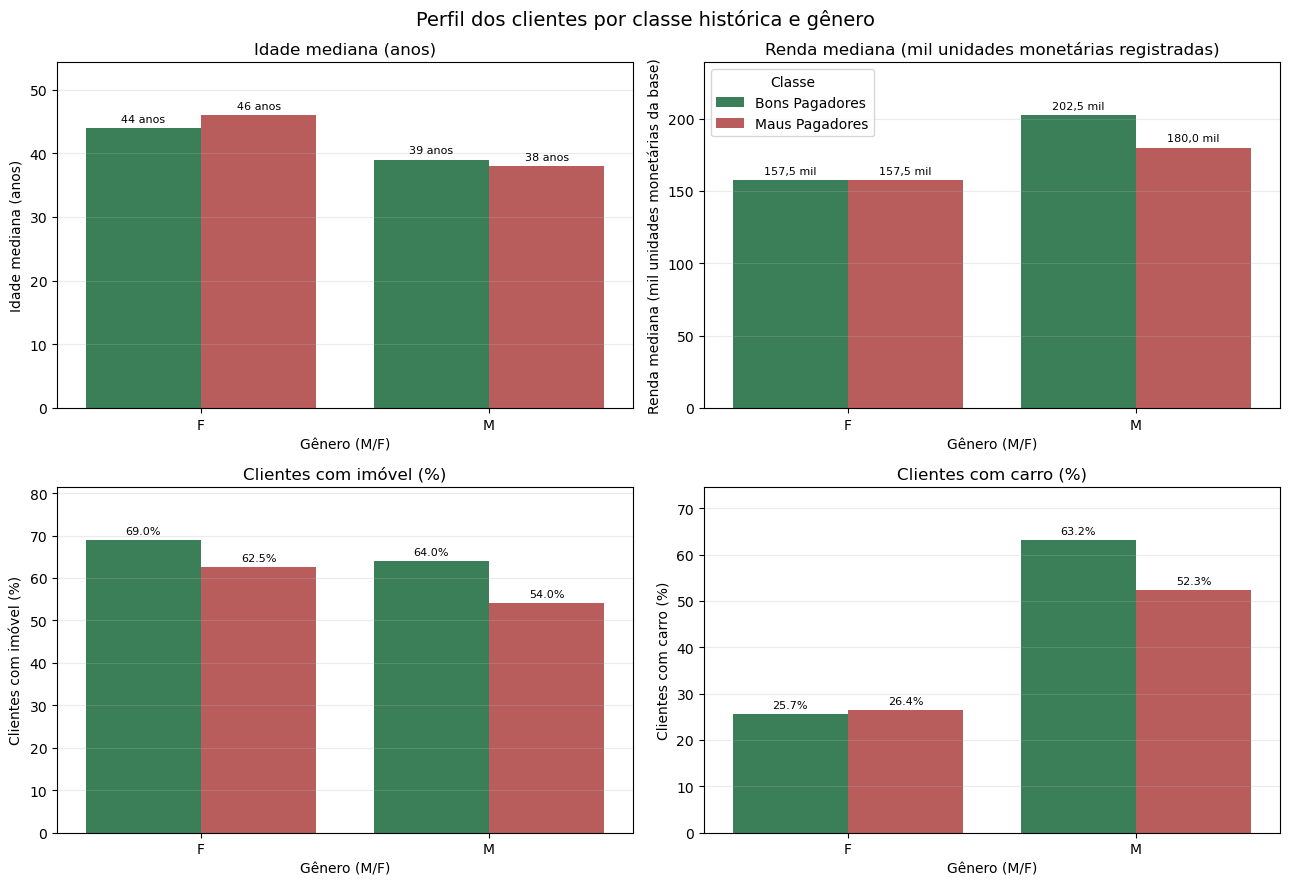

In [54]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

dados_perfil = df_modelagem.assign(
    IDADE_ANOS=(-df_modelagem['DAYS_BIRTH'] / 365.25).astype(int),
    OCUPACAO_ANALISE=df_modelagem['OCCUPATION_TYPE'].fillna('Outros')
)

perfil_cliente = (
    dados_perfil.groupby(['TARGET', 'CODE_GENDER'], as_index=False)
    .agg(
        CLIENTES=('ID', 'size'),
        IDADE_MEDIA_ANOS=('IDADE_ANOS', 'mean'),
        IDADE_MEDIANA_ANOS=('IDADE_ANOS', 'median'),
        RENDA_MEDIA=('AMT_INCOME_TOTAL', 'mean'),
        RENDA_MEDIANA=('AMT_INCOME_TOTAL', 'median'),
        MEDIA_FILHOS=('CNT_CHILDREN', 'mean'),
        TAMANHO_MEDIO_FAMILIA=('CNT_FAM_MEMBERS', 'mean'),
        PCT_POSSUI_IMOVEL=('FLAG_OWN_REALTY', lambda valores: (valores == 'Y').mean() * 100),
        PCT_POSSUI_CARRO=('FLAG_OWN_CAR', lambda valores: (valores == 'Y').mean() * 100),
        PCT_PROFISSAO_SEGURANCA=('OCUPACAO_ANALISE', lambda valores: (valores == 'Security staff').mean() * 100),
        PCT_OUTROS_SEM_OCUPACAO=('OCUPACAO_ANALISE', lambda valores: (valores == 'Outros').mean() * 100),
        PCT_PROFISSAO_TECNOLOGIA=('OCUPACAO_ANALISE', lambda valores: (valores == 'IT staff').mean() * 100)
    )
)

perfil_cliente['Classe'] = perfil_cliente['TARGET'].map({
    0: 'Bons Pagadores',
    1: 'Maus Pagadores'
})

perfil_apresentacao = perfil_cliente.assign(
    Gênero=perfil_cliente['CODE_GENDER'].map({'F': 'Mulheres', 'M': 'Homens'}),
    **{
        'Idade média (mediana), anos': perfil_cliente.apply(
            lambda linha: f"{linha['IDADE_MEDIA_ANOS']:.1f} ({linha['IDADE_MEDIANA_ANOS']:.0f})", axis=1
        ),
        'Renda média (mediana)*': perfil_cliente.apply(
            lambda linha: f"{linha['RENDA_MEDIA']:,.0f} ({linha['RENDA_MEDIANA']:,.0f})"
            .replace(',', 'X').replace('.', ',').replace('X', '.'), axis=1
        )
    }
).rename(columns={
    'Classe': 'Classe histórica',
    'CLIENTES': 'Clientes',
    'MEDIA_FILHOS': 'Filhos (média)',
    'TAMANHO_MEDIO_FAMILIA': 'Pessoas por família (média)',
    'PCT_POSSUI_IMOVEL': 'Com imóvel (%)',
    'PCT_POSSUI_CARRO': 'Com carro (%)',
    'PCT_PROFISSAO_SEGURANCA': 'Profissionais de segurança (%)',
    'PCT_OUTROS_SEM_OCUPACAO': 'Outros/ocupação não informada (%)',
    'PCT_PROFISSAO_TECNOLOGIA': 'Profissionais de TI (%)'
})
colunas_apresentacao = [
    'Classe histórica', 'Gênero', 'Clientes',
    'Idade média (mediana), anos', 'Renda média (mediana)*',
    'Filhos (média)', 'Pessoas por família (média)',
    'Com imóvel (%)', 'Com carro (%)',
    'Profissionais de segurança (%)', 'Outros/ocupação não informada (%)',
    'Profissionais de TI (%)'
]
colunas_percentuais = [
    'Com imóvel (%)', 'Com carro (%)',
    'Profissionais de segurança (%)', 'Outros/ocupação não informada (%)',
    'Profissionais de TI (%)'
]
estilo_tabela = (
    perfil_apresentacao[colunas_apresentacao]
    .style
    .format({
        'Clientes': '{:,.0f}',
        'Filhos (média)': '{:.2f}',
        'Pessoas por família (média)': '{:.2f}',
        **{coluna: '{:.1f}%' for coluna in colunas_percentuais}
    })
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#23415c'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '7px')]},
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('font-size', '11px')]}
    ])
    .hide(axis='index')
)
display(estilo_tabela)

metricas_grafico = [
    ('IDADE_MEDIANA_ANOS', 'Idade mediana (anos)'),
    ('RENDA_MEDIANA', 'Renda mediana (mil unidades monetárias registradas)'),
    ('PCT_POSSUI_IMOVEL', 'Clientes com imóvel (%)'),
    ('PCT_POSSUI_CARRO', 'Clientes com carro (%)')
]

def formatar_rotulo(metrica, valor):
    if metrica == 'RENDA_MEDIANA':
        return f'{valor / 1000:.1f}'.replace('.', ',') + ' mil'
    if metrica.startswith('PCT_'):
        return f'{valor:.1f}%'
    return f'{valor:.0f} anos'

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (metrica, titulo) in zip(axes.flat, metricas_grafico):
    sns.barplot(
        data=perfil_cliente,
        x='CODE_GENDER',
        y=metrica,
        hue='Classe',
        hue_order=['Bons Pagadores', 'Maus Pagadores'],
        palette={'Bons Pagadores': '#2E8B57', 'Maus Pagadores': '#C94C4C'},
        ax=ax
    )
    ax.set_title(titulo)
    ax.set_xlabel('Gênero (M/F)')
    ax.set_ylabel(titulo)
    for container in ax.containers:
        rotulos = [formatar_rotulo(metrica, barra.get_height()) for barra in container]
        ax.bar_label(container, labels=rotulos, padding=3, fontsize=8)
    if metrica == 'RENDA_MEDIANA':
        ax.yaxis.set_major_formatter(FuncFormatter(lambda valor, _: f'{valor / 1000:.0f}'))
        ax.set_ylabel('Renda mediana (mil unidades monetárias da base)')
    ax.margins(y=0.18)
    ax.grid(axis='y', alpha=0.25)

axes[0, 1].legend(title='Classe')
axes[0, 0].get_legend().remove()
axes[1, 0].get_legend().remove()
axes[1, 1].get_legend().remove()
fig.suptitle('Perfil dos clientes por classe histórica e gênero', fontsize=14)
plt.tight_layout()
plt.show()

**Leitura do perfil:** a tabela resume cada combinação de classe histórica e gênero, com médias e medianas para idade e renda, além da média de filhos, do tamanho familiar e de percentuais. Os percentuais são apresentados numericamente e calculados dentro do respectivo grupo. Foram acrescentadas três categorias ocupacionais: profissionais de segurança, profissionais de tecnologia da informação e “Outros/ocupação não informada”. Esta última reúne tanto ocupações ausentes quanto a categoria “Outros”, conforme o tratamento aplicado na preparação dos dados; não representa uma profissão única. O gráfico comparativo abaixo continua restrito às métricas já selecionadas. A base não informa a moeda nem o período da renda, portanto os valores de renda são apresentados apenas nas unidades registradas. A coluna `Clientes` deve ser considerada ao interpretar cada grupo, especialmente os grupos da classe 1, que são menores. As diferenças observadas descrevem os registros desta população; não demonstram que idade, renda, gênero, família, patrimônio ou profissão causem o resultado histórico.

<a id="prep-ausentes"></a>
## 2. Dados ausentes

In [55]:
# 1. Identificação de Dados Faltantes no dataset unificado
nulos = df_modelagem.isnull().sum()
percentual = (df_modelagem.isnull().mean() * 100).round(2)

df_nulos = pd.DataFrame({
    'Quantidade_Nulos': nulos, 
    'Percentual (%)': percentual
})

# Filtrar apenas as colunas que possuem algum valor vazio
colunas_com_nulos = df_nulos[df_nulos['Quantidade_Nulos'] > 0].sort_values(by='Percentual (%)', ascending=False)
print("Resumo de Dados Faltantes:\n")
print(colunas_com_nulos)

Resumo de Dados Faltantes:

                 Quantidade_Nulos  Percentual (%)
OCCUPATION_TYPE             11323           31.06


### 2.1 Diagnóstico e decisão de tratamento

O diagnóstico identifica 11.323 valores ausentes em OCCUPATION_TYPE, equivalentes a 31,06% da população de modelagem. A coluna é preenchida com a categoria Outros, preservando os registros e permitindo codificar a categoria nas etapas seguintes.

In [56]:
# Substituir os valores nulos (NaN) da coluna OCCUPATION_TYPE pela string 'Outros'
df_modelagem['OCCUPATION_TYPE'] = df_modelagem['OCCUPATION_TYPE'].fillna('Outros')

# Validação do tratamento: somar todos os nulos do dataframe
total_nulos = df_modelagem.isnull().sum().sum()

print(f"Total de valores nulos na base após o tratamento: {total_nulos}")

Total de valores nulos na base após o tratamento: 0


**Validação do tratamento:** Após a imputação, a verificação retorna zero valores ausentes. A etapa seguinte trata o marcador identificado em DAYS_EMPLOYED.

<a id="prep-emprego"></a>
## 3. Tratamento do marcador em DAYS_EMPLOYED

O valor 365243 não segue a convenção dos demais registros, que expressam em dias negativos o tempo transcorrido desde a solicitação. Ele é tratado como marcador especial, não como duração literal de emprego, e é substituído por zero. Não é criada uma variável indicadora separada; assim, zero também representa os registros originalmente marcados.

In [57]:
# Verificar a quantidade de registros com o outlier antes do tratamento
qtd_outliers = (df_modelagem['DAYS_EMPLOYED'] == 365243).sum()
print(f"Clientes identificados com o marcador de sistema (365243): {qtd_outliers}")

# Substituir o outlier por 0
df_modelagem['DAYS_EMPLOYED'] = df_modelagem['DAYS_EMPLOYED'].replace(365243, 0)

# Validar o tratamento verificando o novo valor máximo da coluna
novo_max = df_modelagem['DAYS_EMPLOYED'].max()
print(f"Valor máximo em DAYS_EMPLOYED após o tratamento: {novo_max}")

Clientes identificados com o marcador de sistema (365243): 6135
Valor máximo em DAYS_EMPLOYED após o tratamento: 0


### 3.1 Resultado do tratamento

A saída identifica 6.135 registros com o marcador 365243, aproximadamente 16,83% dos 36.457 clientes. Após a substituição, o maior valor de DAYS_EMPLOYED é zero. O resultado confirma a regra aplicada, mas não permite concluir que o marcador identifica exclusivamente desempregados ou aposentados.

<a id="prep-features"></a>
## 4. Engenharia de variáveis

As transformações executadas convertem variáveis temporais para anos, criam renda per capita, codificam categorias e padronizam nomes de colunas. Não são criadas faixas de renda nem aplicadas outras discretizações.

In [58]:
# Verificar e transformar 'DAYS_BIRTH' em 'IDADE_ANOS' apenas se a coluna original ainda existir
if 'DAYS_BIRTH' in df_modelagem.columns:
    df_modelagem['IDADE_ANOS'] = (df_modelagem['DAYS_BIRTH'] / -365.25).astype(int)

# Verificar e transformar 'DAYS_EMPLOYED' em 'TEMPO_EMPREGO_ANOS' apenas se a coluna original ainda existir
if 'DAYS_EMPLOYED' in df_modelagem.columns:
    df_modelagem['TEMPO_EMPREGO_ANOS'] = (df_modelagem['DAYS_EMPLOYED'] / -365.25)
    # Correção de precisão: Ajustar valores resultantes em -0.0 para 0 absoluto
    df_modelagem['TEMPO_EMPREGO_ANOS'] = df_modelagem['TEMPO_EMPREGO_ANOS'].apply(lambda x: 0.0 if x == -0.0 or x == 0.0 else x)
    df_modelagem['TEMPO_EMPREGO_ANOS'] = df_modelagem['TEMPO_EMPREGO_ANOS'].round(2)

# Excluir de forma segura as colunas originais em dias (caso ainda existam) para evitar redundância
colunas_dias_originais = ['DAYS_BIRTH', 'DAYS_EMPLOYED']
df_modelagem.drop(columns=[col for col in colunas_dias_originais if col in df_modelagem.columns], inplace=True)

# Visualizar as primeiras linhas para confirmar a transformação estrutural
print("Transformação temporal validada com sucesso.")
display(df_modelagem[['IDADE_ANOS', 'TEMPO_EMPREGO_ANOS']].head())

Transformação temporal validada com sucesso.


,IDADE_ANOS,TEMPO_EMPREGO_ANOS
0,32,12.44
1,32,12.44
2,58,3.10
3,52,8.35
4,52,8.35


### 4.1 Conversão das variáveis temporais

DAYS_BIRTH e DAYS_EMPLOYED são divididas por -365,25 para gerar idade e tempo de emprego em anos. O marcador convertido para zero resulta em zero ano de emprego na variável derivada. As colunas originais em dias são removidas para evitar manter duas representações da mesma grandeza.

In [59]:
# 1. Traduzir as colunas originais para o português
df_modelagem.rename(columns={
    'AMT_INCOME_TOTAL': 'RENDA_TOTAL',
    'CNT_FAM_MEMBERS': 'QTD_MEMBROS_FAMILIA'
}, inplace=True)

# 2. Criação da variável de Renda Per Capita com as colunas traduzidas
df_modelagem['RENDA_PER_CAPITA'] = df_modelagem['RENDA_TOTAL'] / df_modelagem['QTD_MEMBROS_FAMILIA']

# 3. Arredondar para duas casas decimais
df_modelagem['RENDA_PER_CAPITA'] = df_modelagem['RENDA_PER_CAPITA'].round(2)

# 4. Visualizar as 5 primeiras linhas para confirmar a transformação
df_modelagem[['RENDA_TOTAL', 'QTD_MEMBROS_FAMILIA', 'RENDA_PER_CAPITA']].head()

,RENDA_TOTAL,QTD_MEMBROS_FAMILIA,RENDA_PER_CAPITA
0,427500.0,2.0,213750.0
1,427500.0,2.0,213750.0
2,112500.0,2.0,56250.0
3,270000.0,1.0,270000.0
4,270000.0,1.0,270000.0


### 4.2 Criação da renda per capita

RENDA_PER_CAPITA é calculada pela divisão de RENDA_TOTAL por QTD_MEMBROS_FAMILIA. O atributo complementa a renda total com o tamanho do grupo familiar; não é uma medida direta de capacidade de pagamento nem substitui a renda total.

### 4.3 Codificação de variáveis categóricas

As flags binárias são convertidas para valores numéricos, e as demais categorias são codificadas com pd.get_dummies(drop_first=True). A remoção da primeira categoria evita uma coluna redundante de referência, especialmente relevante para modelos lineares.

In [60]:
# 1. Converter flags binárias de texto ('Y'/'N') para numéricas (1/0)
binarias_yn = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
for col in binarias_yn:
    if col in df_modelagem.columns:
        df_modelagem[col] = df_modelagem[col].apply(lambda x: 1 if str(x).strip().upper() == 'Y' else 0)

# 2. Converter a coluna de Gênero ('M'/'F') para binária (ex: GENERO_MASCULINO: 1 para M, 0 para F)
if 'CODE_GENDER' in df_modelagem.columns:
    df_modelagem['CODE_GENDER_M'] = df_modelagem['CODE_GENDER'].apply(lambda x: 1 if str(x).strip().upper() == 'M' else 0)
    df_modelagem.drop(columns=['CODE_GENDER'], inplace=True)

# 3. Identificar as demais colunas categóricas (tipo texto/'object') remanescentes
colunas_categoricas = df_modelagem.select_dtypes(include=['object']).columns
print(f"Colunas categóricas que serão codificadas:\n{list(colunas_categoricas)}\n")

# 4. Aplicar o One-Hot Encoding com drop_first=True para evitar multicolinearidade
df_modelagem = pd.get_dummies(df_modelagem, columns=colunas_categoricas, drop_first=True, dtype=int)

# 5. Tratamento de redundâncias (remover colunas originais em dias para evitar multicolinearidade com as versões em anos)
colunas_para_remover = ['DAYS_BIRTH', 'DAYS_EMPLOYED']
for col in colunas_para_remover:
    if col in df_modelagem.columns:
        df_modelagem.drop(columns=[col], inplace=True)

# Verificar a nova estrutura do dataset higienizado
print(f"Nova dimensão do dataset após o tratamento completo e Encoding: {df_modelagem.shape}")

# Visualizar as primeiras linhas com todas as colunas numéricas prontas
df_modelagem.head()

Colunas categóricas que serão codificadas:
['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

Nova dimensão do dataset após o tratamento completo e Encoding: (36457, 50)


,ID,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,RENDA_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,QTD_MEMBROS_FAMILIA,...,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Outros,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff
0,5008804,1,1,0,427500.0,1,1,0,0,2.0,...,0,0,0,1,0,0,0,0,0,0
1,5008805,1,1,0,427500.0,1,1,0,0,2.0,...,0,0,0,1,0,0,0,0,0,0
2,5008806,1,1,0,112500.0,1,0,0,0,2.0,...,0,0,0,0,0,0,0,0,1,0
3,5008808,0,1,0,270000.0,1,0,1,1,1.0,...,0,0,0,0,0,0,1,0,0,0
4,5008809,0,1,0,270000.0,1,0,1,1,1.0,...,0,0,0,0,0,0,1,0,0,0


### 4.3.1 Resultado da codificação

A saída lista as categorias codificadas e apresenta a nova dimensão do conjunto. As colunas resultantes são numéricas e podem ser fornecidas aos classificadores. A codificação não implica que as categorias tenham uma ordem natural.

In [61]:
# Dicionário abrangente para traduzir prefixos e categorias do dataset original
dicionario_traducao = {
    # Traduções de colunas originais e prefixos
    'FLAG_MOBIL': 'TEM_TELEMÓVEL',
    'FLAG_WORK_PHONE': 'TEM_TELEFONE_TRABALHO',
    'FLAG_PHONE': 'TEM_TELEFONE_FIXO',
    'FLAG_EMAIL': 'TEM_EMAIL',
    'CODE_GENDER_M': 'GENERO_MASCULINO',
    'FLAG_OWN_CAR_Y': 'POSSUI_CARRO_SIM',
    'FLAG_OWN_REALTY_Y': 'POSSUI_IMOVEL_SIM',
    'NAME_INCOME_TYPE_': 'TIPO_RENDA_',
    'NAME_EDUCATION_TYPE_': 'ESCOLARIDADE_',
    'NAME_FAMILY_STATUS_': 'ESTADO_CIVIL_',
    'NAME_HOUSING_TYPE_': 'TIPO_HABITACAO_',
    'OCCUPATION_TYPE_': 'PROFISSAO_',
    
    # Traduções dos valores categóricos que viraram sufixos
    'Commercial associate': 'Associado_Comercial',
    'Pensioner': 'Pensionista',
    'State servant': 'Servidor_Publico',
    'Student': 'Estudante',
    'Working': 'Trabalhador_Ativo',
    'Higher education': 'Ensino_Superior',
    'Incomplete higher': 'Superior_Incompleto',
    'Lower secondary': 'Ensino_Fundamental',
    'Secondary / secondary special': 'Ensino_Medio',
    'Civil marriage': 'Casamento_Civil',
    'Married': 'Casado',
    'Separated': 'Separado',
    'Single / not married': 'Solteiro',
    'Widow': 'Viuvo',
    'Co-op apartment': 'Apto_Cooperativa',
    'House / apartment': 'Casa_Apto',
    'Municipal apartment': 'Apto_Municipal',
    'Office apartment': 'Apto_Escritorio',
    'Rented apartment': 'Apto_Alugado',
    'With parents': 'Com_Os_Pais'
}

# Iterar sobre o dicionário e substituir os termos nos nomes das colunas
novas_colunas = df_modelagem.columns
for termo_ingles, termo_portugues in dicionario_traducao.items():
    novas_colunas = novas_colunas.str.replace(termo_ingles, termo_portugues, regex=False)

# Aplicar os novos nomes ao dataset e remover espaços em branco por *underscores*
df_modelagem.columns = novas_colunas.str.replace(' ', '_')

# Visualizar a lista atualizada de colunas em formato de lista Python
print("Colunas formatadas e traduzidas:")
lista_colunas = df_modelagem.columns.tolist()
print(lista_colunas)

Colunas formatadas e traduzidas:
['ID', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'RENDA_TOTAL', 'TEM_TELEMÓVEL', 'TEM_TELEFONE_TRABALHO', 'TEM_TELEFONE_FIXO', 'TEM_EMAIL', 'QTD_MEMBROS_FAMILIA', 'TARGET', 'IDADE_ANOS', 'TEMPO_EMPREGO_ANOS', 'RENDA_PER_CAPITA', 'GENERO_MASCULINO', 'TIPO_RENDA_Pensionista', 'TIPO_RENDA_Servidor_Publico', 'TIPO_RENDA_Estudante', 'TIPO_RENDA_Trabalhador_Ativo', 'ESCOLARIDADE_Ensino_Superior', 'ESCOLARIDADE_Superior_Incompleto', 'ESCOLARIDADE_Ensino_Fundamental', 'ESCOLARIDADE_Ensino_Medio', 'ESTADO_CIVIL_Casado', 'ESTADO_CIVIL_Separado', 'ESTADO_CIVIL_Solteiro', 'ESTADO_CIVIL_Viuvo', 'TIPO_HABITACAO_Casa_Apto', 'TIPO_HABITACAO_Apto_Municipal', 'TIPO_HABITACAO_Apto_Escritorio', 'TIPO_HABITACAO_Apto_Alugado', 'TIPO_HABITACAO_Com_Os_Pais', 'PROFISSAO_Cleaning_staff', 'PROFISSAO_Cooking_staff', 'PROFISSAO_Core_staff', 'PROFISSAO_Drivers', 'PROFISSAO_HR_staff', 'PROFISSAO_High_skill_tech_staff', 'PROFISSAO_IT_staff', 'PROFISSAO_Laborers', 'PROFISSAO_L

### 4.4 Padronização dos nomes das variáveis

Os nomes das colunas e os sufixos das categorias são traduzidos para português, e os espaços são substituídos por sublinhados. A etapa melhora a consistência dos identificadores exibidos em tabelas e gráficos; não altera valores nem o significado estatístico das variáveis.

<a id="prep-escalonamento"></a>
## 5. Escalonamento

O escalonamento é adiado até a divisão entre treino e teste para que seus parâmetros não sejam ajustados com dados de teste. No Notebook 03, StandardScaler é ajustado com os dados de treino da Regressão Logística; no Random Forest, o escalonador está dentro do pipeline, embora não seja necessário para árvores.

<a id="prep-exportacao"></a>
## 6. Exportação do conjunto tratado

In [62]:
from pathlib import Path

# Definir o caminho para o diretório de dados processados
PROCESSED = Path("../data/processed")

# Criar a pasta caso ela ainda não exista na estrutura do projeto
PROCESSED.mkdir(parents=True, exist_ok=True)

# Exportar o dataframe final para CSV (sem a coluna de índice do Pandas)
df_modelagem.to_csv(PROCESSED / "dataset_tratado.csv", index=False)

print(f"Dataset de modelagem salvo com sucesso em: {PROCESSED / 'dataset_tratado.csv'}")

Dataset de modelagem salvo com sucesso em: ..\data\processed\dataset_tratado.csv


### 6.1 Salvamento do arquivo

A base é exportada sem índice para ../data/processed/dataset_tratado.csv. A saída confirma o caminho informado pelo código. O arquivo inclui o alvo e as features numéricas resultantes da imputação, das transformações temporais, da renda per capita e da codificação categórica.

<a id="prep-conclusao"></a>
## 7. Conclusão do pré-processamento

Neste notebook, cruzamos o cadastro de clientes com o histórico de crédito por identificador e mantivemos os clientes presentes nas duas fontes. A população resultante tem 36.457 clientes: 35.841 na classe `TARGET=0` (98,31%) e 616 na classe `TARGET=1` (1,69%). O alvo é retrospectivo: indica se houve atraso grave observado no histórico disponível, não prevê diretamente um evento futuro em um prazo definido.

Em seguida, identificamos 11.323 valores ausentes em ocupação (31,06%) e os agrupamos na categoria “Outros”; também substituímos o marcador `DAYS_EMPLOYED=365243` por zero em 6.135 registros (aproximadamente 16,83%). Transformamos idade e tempo de emprego de dias para anos, criamos renda per capita, codificamos variáveis categóricas e padronizamos nomes. Exportamos a base tratada para `data/processed/dataset_tratado.csv`. O escalonamento foi deixado para depois da divisão entre treino e teste, para evitar ajustar esse pré-processamento com informações do conjunto de teste.

As análises descritivas mostram diferenças de idade, renda, composição familiar, posse de bens e ocupação entre classes históricas e gêneros. Por exemplo, a proporção de homens com carro é menor no grupo com atraso grave observado do que no grupo sem atraso grave observado. Essas comparações descrevem esta população; não demonstram causas nem permitem, sozinhas, afirmar que uma característica separa ou prevê corretamente as classes.

A classe `TARGET=1` representa apenas 1,69% dos clientes cruzados. Essa forte diferença de proporção precisa ser considerada na modelagem e na avaliação: uma acurácia alta, isoladamente, não comprovaria que o modelo identifica bem os casos de atraso grave. O pré-processamento prepara a base para a etapa seguinte, mas ainda não demonstra capacidade preditiva, qualidade operacional ou desempenho em dados novos. Essas conclusões dependem dos resultados de modelagem e avaliação nos notebooks seguintes.